# **10x Visium RCC: data processing**

In [1]:
import os
import json
import numpy as np
import pandas as pd
import liana as li
import scanpy as sc
import anndata as ad
import muon as mu
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from pyimzml.ImzMLParser import ImzMLParser
from scipy.ndimage import gaussian_filter
from matplotlib.colors import ListedColormap
from skimage.transform import resize
from skimage.registration import phase_cross_correlation
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")


BASE_PATH = "/home/projects/nyosef/oier/Harreman_files/Revision/Visium_RCC"
ST_RAW_DATA_PATH = os.path.join(BASE_PATH, 'ST_visium')
SM_RAW_DATA_PATH = os.path.join(BASE_PATH, 'spatial_metabolomics')
ADATA_PATH = os.path.join(BASE_PATH, 'h5ads')
DATA_PATH = os.path.join(BASE_PATH, 'data')

/home/projects/nyosef/oier/mambaforge/envs/liana_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
/home/projects/nyosef/oier/mambaforge/envs/liana_env/lib/python3.12/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead


## Load ST dataset

The data was obtained from https://zenodo.org/record/8063124.

In [2]:
samples = [sample for sample in os.listdir(ST_RAW_DATA_PATH) if not sample.startswith('.')]

In [3]:
st_adatas = {}
for sample in samples:
    sample_adata_path = f'{ST_RAW_DATA_PATH}/{sample}/outs' if 'outs' in os.listdir(f'{ST_RAW_DATA_PATH}/{sample}') else f'{ST_RAW_DATA_PATH}/{sample}'
    sample_adata = sc.read_visium(sample_adata_path)
    sample_adata.var_names_make_unique()
    sample_adata.obs['sample'] = sample
    sample_adata.obs_names = [f'{barcode}_{sample}' for barcode in sample_adata.obs_names]
    
    sample_adata.layers['counts'] = sample_adata.X
    norm = sc.pp.normalize_total(sample_adata, target_sum=1e4, inplace=False)
    sample_adata.layers["normalized"] = norm["X"]
    sample_adata.layers["log_norm"] = sc.pp.log1p(norm["X"], copy=True)
    
    st_adatas[sample] = sample_adata

In [4]:
st_adata = ad.concat(st_adatas.values())

In [5]:
st_adata.var = sample_adata.var

In [6]:
st_adata

AnnData object with n_obs × n_vars = 46398 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'sample'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'
    layers: 'counts', 'normalized', 'log_norm'

In [7]:
# st_adata.write(f'{ADATA_PATH}/ST_adata.h5ad')

In [2]:
st_adata = ad.read_h5ad(f'{ADATA_PATH}/ST_adata.h5ad')

In [5]:
st_adata.obs['sample'].value_counts()

sample
X98_T     4982
R_med     4599
R29_T     4335
R_cor     4171
H46_T     3709
Z43_T     3696
X49_T     3068
Y27_T     3055
R51_T     3034
J38_T     2937
S15_T     2846
R114_T    2244
Y7_T      2018
Y12_T     1704
Name: count, dtype: int64

## Load both modalities together

In [2]:
samples = [sample for sample in os.listdir(ST_RAW_DATA_PATH) if not sample.startswith('.')]

In [3]:
samples_of_interest = ['R_cor', 'Z43_T', 'Y7_T', 'R114_T', 'R51_T', 'R29_T']

In [4]:
def build_reference_mz(parser, n_pixels=2000):
    mz_all = []
    
    for i in range(min(n_pixels, len(parser.coordinates))):
        mz, _ = parser.getspectrum(i)
        mz_all.append(mz)
    
    mz_all = np.concatenate(mz_all)
    
    # round to merge nearby peaks (this replaces binning)
    mz_ref = np.unique(np.round(mz_all, 3))  # precision ~0.001
    
    return mz_ref

In [5]:
def extract_all_mz(parser, mz_ref, tol=0.01):
    n_pixels = len(parser.coordinates)
    n_features = len(mz_ref)
    
    X = np.zeros((n_pixels, n_features), dtype=np.float32)
    
    for i in range(n_pixels):
        mzs, intensities = parser.getspectrum(i)
        
        for j, target_mz in enumerate(mz_ref):
            idx = np.abs(mzs - target_mz).argmin()
            
            if np.abs(mzs[idx] - target_mz) < tol:
                X[i, j] = intensities[idx]
    
    return X

In [6]:
def plot_mz_from_anndata(adata, target_mz, coords_key="spatial", tol=0.01, smooth=True):
    
    # 1. find closest mz in AnnData
    mz_values = adata.var["mz"].values
    idx = np.abs(mz_values - target_mz).argmin()
    
    if np.abs(mz_values[idx] - target_mz) > tol:
        print("Warning: no close m/z found")
    
    # 2. extract intensities
    values = adata.X[:, idx]
    
    if hasattr(values, "toarray"):
        values = values.toarray().flatten()
    else:
        values = np.asarray(values).flatten()
    
    # 3. build image (same as your code)
    coords = adata.obsm[coords_key]
    xs, ys = coords[:, 0], coords[:, 1]
    
    img = np.zeros((ys.max(), xs.max()))
    
    for i, (x, y) in enumerate(coords):
        img[y-1, x-1] = values[i]
    
    # 4. smoothing (like Cardinal)
    if smooth:
        img = gaussian_filter(img, sigma=1)
    
    # 5. histogram normalization (like Cardinal)
    p1, p99 = np.percentile(img, [1, 99])
    img = np.clip((img - p1) / (p99 - p1), 0, 1)
    
    # 6. plot
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap="jet")
    plt.colorbar()
    plt.title(f"m/z {mz_values[idx]:.4f}")
    plt.axis("off")
    plt.show()

In [7]:
def build_total_intensity_image(adata):
    coords = adata.obsm["spatial"]
    xs, ys = coords[:, 0], coords[:, 1]
    
    img = np.zeros((ys.max(), xs.max()))
    values = adata.obs["total_intensity"].values
    
    img[ys-1, xs-1] = values
    return img

In [8]:
def normalize(img):
    p1, p99 = np.percentile(img, [1, 99])
    return np.clip((img - p1) / (p99 - p1), 0, 1)

In [9]:
def _prettify_axis(ax, spatial=False):
    # Hide the right and top spines
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    # Only show ticks on the left and bottom spines
    ax.yaxis.set_ticks_position("left")
    ax.xaxis.set_ticks_position("bottom")
    if spatial:
        plt.xticks([])
        plt.yticks([])
        plt.xlabel("Spatial1")
        plt.ylabel("Spatial2")

In [10]:
def plot_interaction(adata, scores, interaction, coords_obsm_key, s, vmin, vmax, figsize, cmap, colorbar, swap_y_axis, title):

    if isinstance(adata.obsm[coords_obsm_key], pd.DataFrame):
        coords = adata.obsm[coords_obsm_key].values
    else:
        coords = adata.obsm[coords_obsm_key]
    
    ax = plt.subplot(111)
    ax.set_aspect('equal', adjustable='box')
    _prettify_axis(ax, spatial=True)
    if swap_y_axis:
        plt.scatter(coords[:,0], -coords[:,1], c=scores[interaction], cmap=cmap, s=s, vmin=vmin, vmax=vmax)
    else:
        plt.scatter(coords[:,0], coords[:,1], c=scores[interaction], cmap=cmap, s=s, vmin=vmin, vmax=vmax)
    plt.title(title)
    if colorbar:
        plt.colorbar()

In [11]:
offset_dict = {
    'R29_T': {
        'pos': {
            'x_offset': -1000,
            'y_offset': -1000,
            'degree': 5,
            },
        'neg': {
            'x_offset': -1000,
            'y_offset': -1000,
            'degree': 3,
            }},
    'R51_T': {
        'pos': {
            'x_offset': 800,
            'y_offset': 0,
            },
        'neg': {
            'x_offset': 500,
            'y_offset': 0,
            }},
    'Y7_T': {
        'pos': {
            'x_offset': 500,
            'y_offset': 500,
            'degree': 4,
            },
        'neg': {
            'x_offset': 500,
            'y_offset': 500,
            'degree': 5,
            }},
    'R_cor': {
        'neg': {
            'x_offset': -500,
            'y_offset': -500,
            'degree': 0,
            }},
    'R114_T': {
        'neg': {
            'x_offset': 500,
            'y_offset': -1000,
            'degree': 0,
            }},
}

Save all MSI samples

J38_T


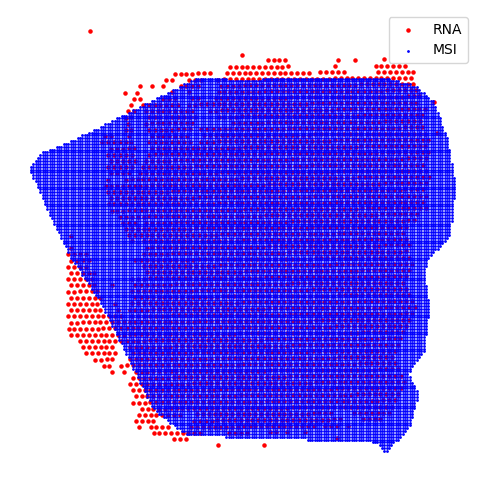

Y7_T


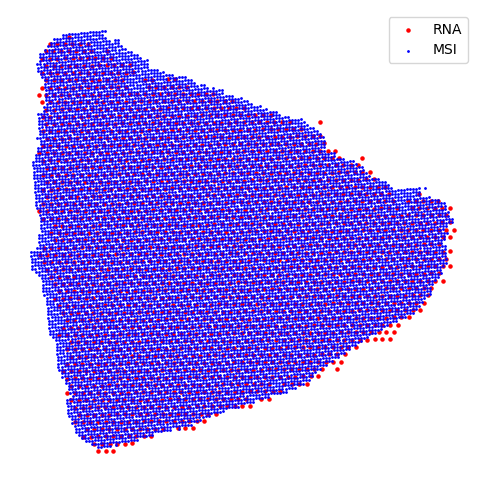

S15_T


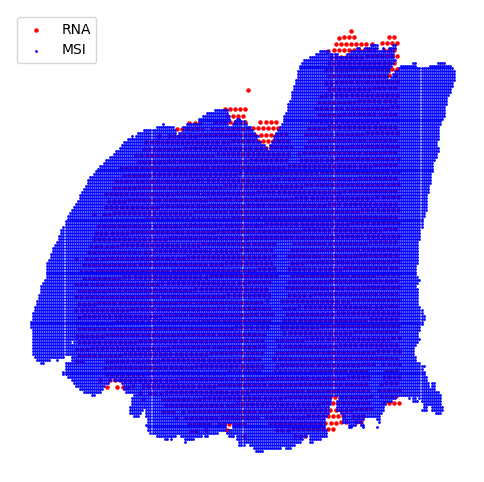

Y12_T


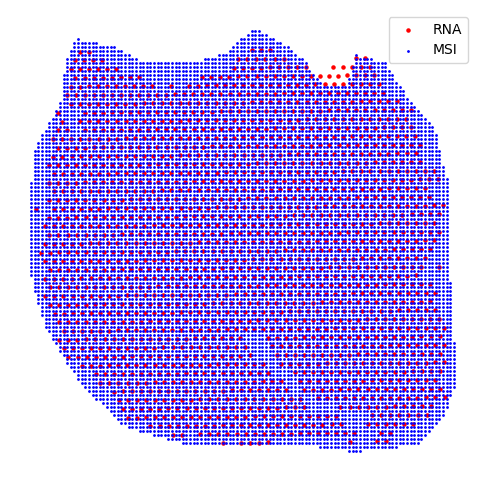

R_med


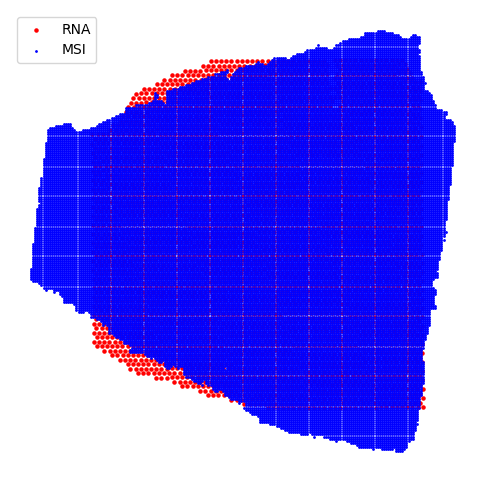

R51_T


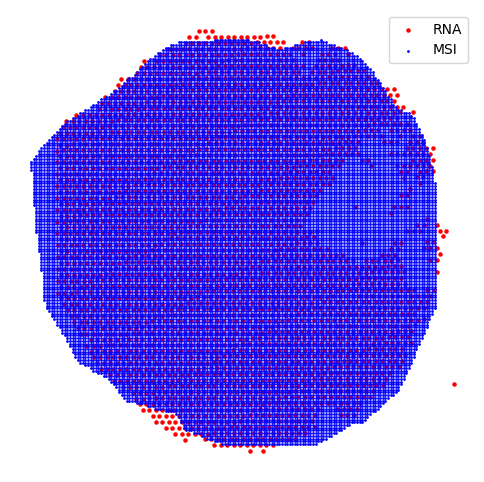

R114_T


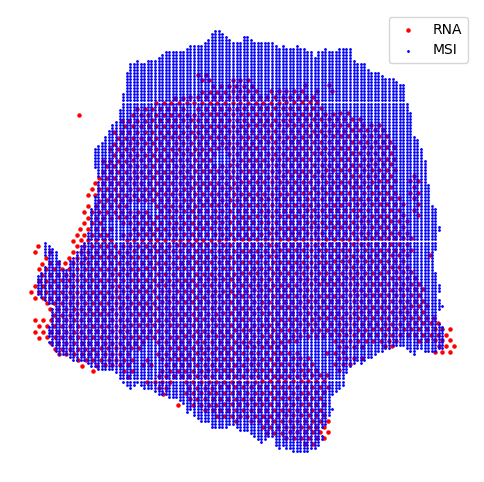

X49_T


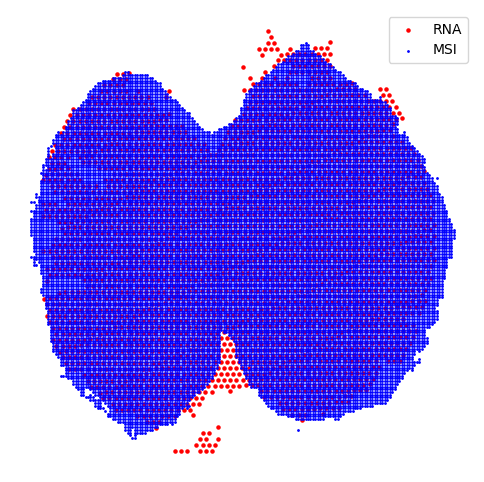

X98_T


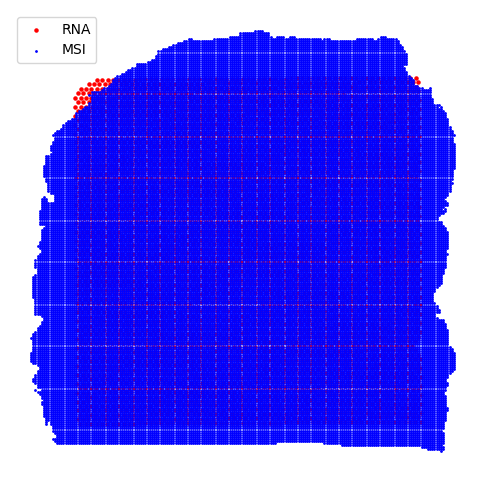

R_cor


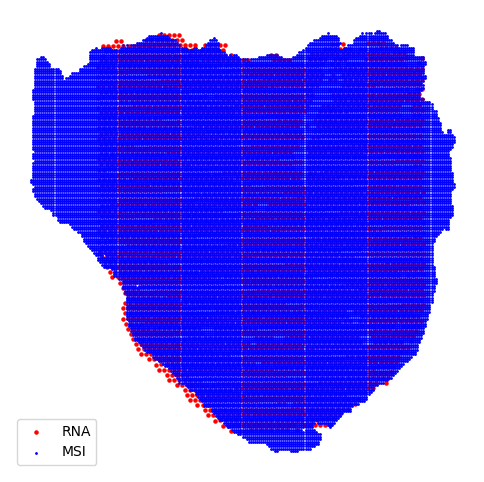

R29_T


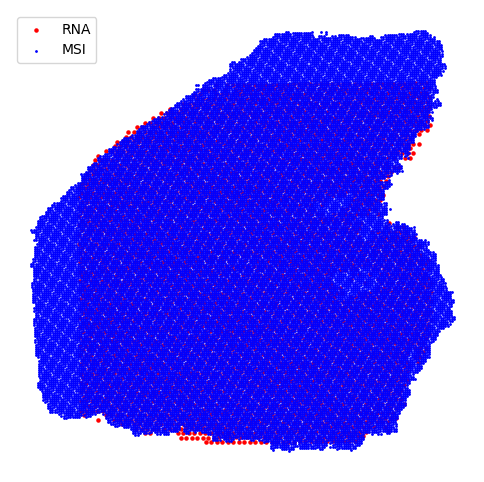

Z43_T


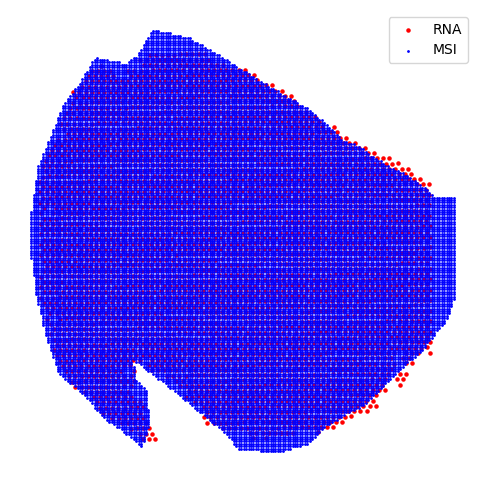

H46_T


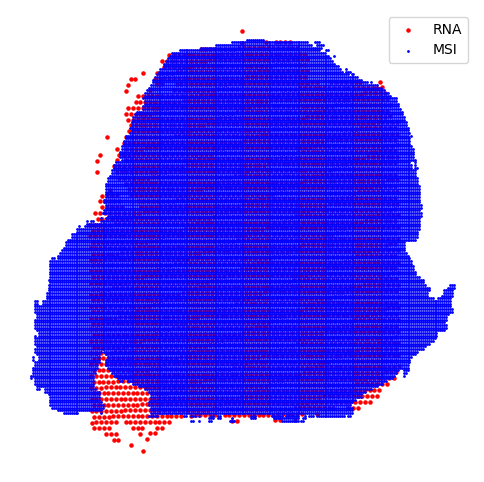

Y27_T


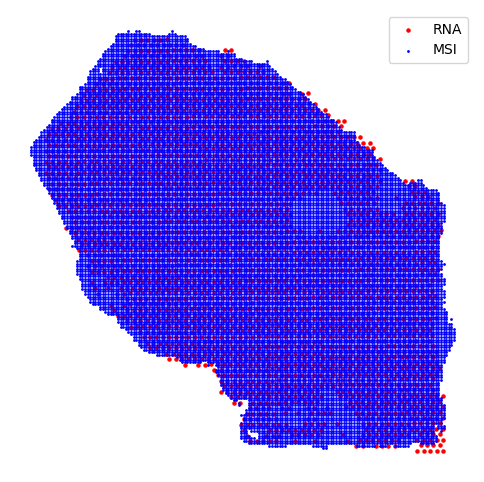

In [12]:
msi_datas = {}
for sample in samples:
    print(sample)
    rna_path = f'{ST_RAW_DATA_PATH}/{sample}/outs' if 'outs' in os.listdir(f'{ST_RAW_DATA_PATH}/{sample}') else f'{ST_RAW_DATA_PATH}/{sample}'
    rna = sc.read_visium(rna_path)
    rna.obs[['x', 'y']] = rna.obsm['spatial']

    # estimate scaling factor
    sfactor = rna.uns['spatial'][sample]['scalefactors']['fiducial_diameter_fullres']
    
    img_he = rna.uns["spatial"][sample]["images"]["hires"]
    img_he_gray = img_he.mean(axis=2)
    img_he_gray = normalize(img_he_gray)
    
    ### Process RNA
    rna.var_names_make_unique()
    
    # Normalize 
    rna.layers['counts'] = rna.X.copy()
    norm = sc.pp.normalize_total(rna, target_sum=1e4, inplace=False)
    rna.layers["normalized"] = norm["X"]
    rna.layers["log_norm"] = sc.pp.log1p(norm["X"], copy=True)
    
    rna.obs['sample'] = sample
    rna.obs_names = [f'{barcode}_{sample}' for barcode in rna.obs_names]

    for mode in ['neg']:
        imzml_file = f"{SM_RAW_DATA_PATH}/{sample.replace('_', '-')}-{mode}.imzML"
        parser = ImzMLParser(imzml_file)
        coords = np.array(parser.coordinates)
        
        xs, ys = coords[:, 0], coords[:, 1]
        
        W = xs.max()
        H = ys.max()
        
        x_new = ys
        y_new = W - xs + 1
        
        positions = np.vstack([x_new, y_new]).T
        
        mz_ref = build_reference_mz(parser)
        
        tol = 0.001

        X = np.zeros((len(parser.coordinates), len(mz_ref)), dtype=np.float32)

        for i in range(len(parser.coordinates)):
            mzs, intensities = parser.getspectrum(i)

            diff = np.abs(mzs[:, None] - mz_ref[None, :]) < tol
            X[i] = (diff * intensities[:, None]).sum(axis=0)
        
        array_row, array_col = positions[:,0], positions[:, 1]

        extra_factor = 0.44 if sample == 'R114_T' else 0.38
        positions = np.round(positions * sfactor * extra_factor).astype(int)

        msi_mode = ad.AnnData(
            X=X,
            obs=pd.DataFrame({"x": coords[:, 0], "y": coords[:, 1], "sample": sample, "mode": mode}),
            var=pd.DataFrame({"mz": mz_ref}, index=[f"mz_{i}" for i in range(len(mz_ref))])
        )
        
        msi_mode.obs.index = msi_mode.obs[['x', 'y']].astype(str).agg('_'.join, axis=1)
        
        msi_mode.obsm['spatial'] = positions
        msi_mode.obs[['x', 'y']] = positions
        msi_mode.obs['array_row'] = array_row
        msi_mode.obs['array_col'] = array_col

        msi_mode.layers['raw'] = msi_mode.X.copy()
        msi_mode.uns = rna.uns.copy()
        
        msi_mode.obs["total_intensity"] = np.array(msi_mode.X.sum(axis=1)).flatten()
        msi_mode.obs["n_metabolites"] = np.array((msi_mode.X > 0).sum(axis=1)).flatten()
        
        msi_mode = msi_mode[
            (msi_mode.obs["total_intensity"] > np.percentile(msi_mode.obs["total_intensity"], 10)) &
            (msi_mode.obs["n_metabolites"] > np.percentile(msi_mode.obs["n_metabolites"], 10))
        ].copy()
        
        coords_rna = rna.obsm["spatial"]
        coords_msi = msi_mode.obsm["spatial"]
        center_rna = coords_rna.mean(axis=0)
        center_msi = coords_msi.mean(axis=0)
        
        center_rna = coords_rna.mean(axis=0)
        center_msi = coords_msi.mean(axis=0)
        
        shift = center_rna - center_msi
        
        coords_msi += np.round(shift).astype(int)
        
        x_offset = offset_dict[sample][mode]['x_offset'] if sample in offset_dict.keys() else 0
        y_offset = offset_dict[sample][mode]['y_offset'] if sample in offset_dict.keys() else 0
        coords_msi[:, 0] = coords_msi[:, 0] + x_offset
        coords_msi[:, 1] = coords_msi[:, 1] + y_offset
        
        if sample == 'R29_T':
            # --- ROTATION STEP ---
            coords = coords_msi.astype(float)

            # 1. define pivot (top-right)
            pivot = np.array([
                coords[:, 0].max(),
                coords[:, 1].min()
            ])

            # 2. rotation angle (tune this!)
            angle_deg = offset_dict[sample][mode]['degree']
            theta = -np.deg2rad(angle_deg)

            # 3. rotation matrix
            R = np.array([
                [np.cos(theta), -np.sin(theta)],
                [np.sin(theta),  np.cos(theta)]
            ])

            # 4. rotate around pivot
            coords = coords - pivot
            coords = coords @ R.T
            coords = coords + pivot

            # 5. (optional) round back to int if needed
            coords_msi = np.round(coords).astype(int)
            
            x_offset = -500 if mode == 'pos' else 0
            y_offset = - 500
            coords_msi[:, 0] = coords_msi[:, 0] + x_offset
            coords_msi[:, 1] = coords_msi[:, 1] + y_offset
        
        if sample == 'Y7_T':
            # --- ROTATION STEP ---
            coords = coords_msi.astype(float)

            # 1. define pivot (bottom-left)
            pivot = np.array([
                coords[:, 0].min(),
                coords[:, 1].max()
            ])

            # 2. rotation angle (tune this!)
            angle_deg = offset_dict[sample][mode]['degree']
            theta = -np.deg2rad(angle_deg)

            # 3. rotation matrix
            R = np.array([
                [np.cos(theta), -np.sin(theta)],
                [np.sin(theta),  np.cos(theta)]
            ])

            # 4. rotate around pivot
            coords = coords - pivot
            coords = coords @ R.T
            coords = coords + pivot

            # 5. (optional) round back to int if needed
            coords_msi = np.round(coords).astype(int)

        msi_mode.obsm["spatial"] = coords_msi
        msi_mode.obs[["x", "y"]] = coords_msi
        
        plt.figure(figsize=(6,6))
        plt.scatter(coords_rna[:,0], coords_rna[:,1], s=5, c="red", label="RNA")
        plt.scatter(coords_msi[:,0], coords_msi[:,1], s=1, c="blue", label="MSI")
        plt.legend()
        plt.gca().invert_yaxis()
        plt.axis("off")
        plt.show()
        
        metabolite_names = msi_mode.var_names.tolist()
        msi_scores = pd.DataFrame(msi_mode.X,
                                    index=msi_mode.obs_names,
                                    columns=metabolite_names)
        
        ### Process metabolites
        msi_mode.X = msi_mode.layers['raw'].copy()
        msi_mode.var['max_intensity'] = msi_mode.X.sum(axis=0)

        # drop duplicates
        msi_mode = msi_mode[:, ~msi_mode.var.index.duplicated()]
        sc.pp.filter_cells(msi_mode, min_counts=200)
        
        msi_mode.obs_names = [f'{barcode}_{sample}_{mode}' for barcode in msi_mode.obs_names]
        
        msi_datas[f"{sample}_{mode}"] = msi_mode

In [13]:
msi_neg_datas = {}
for sample, msi_ in msi_datas.items():
    msi_neg_datas[sample] = msi_

In [14]:
msi_neg = ad.concat(msi_neg_datas.values(), join="outer")

In [15]:
msi_neg.var['mz'] = msi_neg_datas['R29_T_neg'].var['mz']

In [16]:
# msi_neg.write(os.path.join(f"{ADATA_PATH}/neg_msi_all.h5ad"))

... storing 'sample' as categorical
... storing 'mode' as categorical


Save samples of interest

R_cor


... storing 'sample' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical


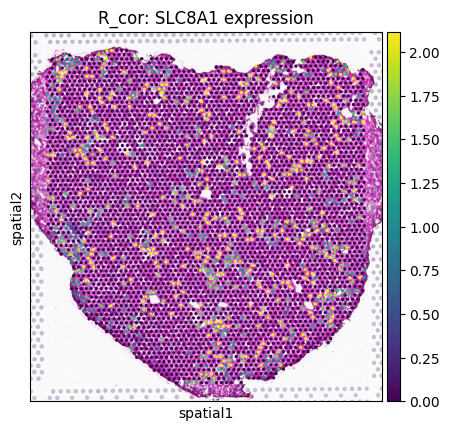

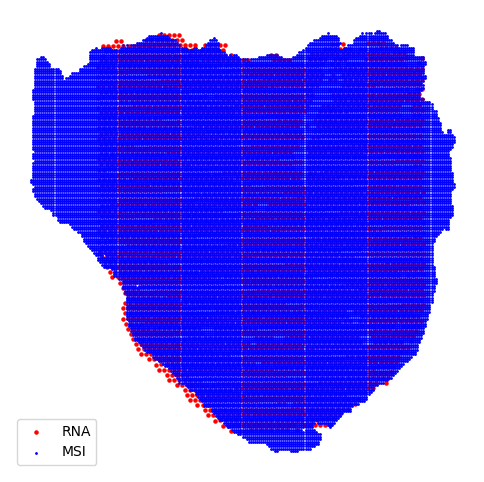

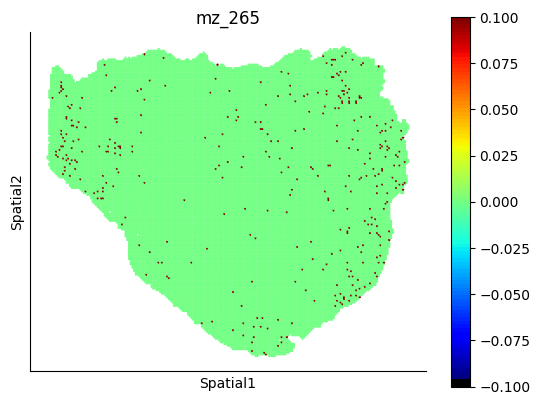

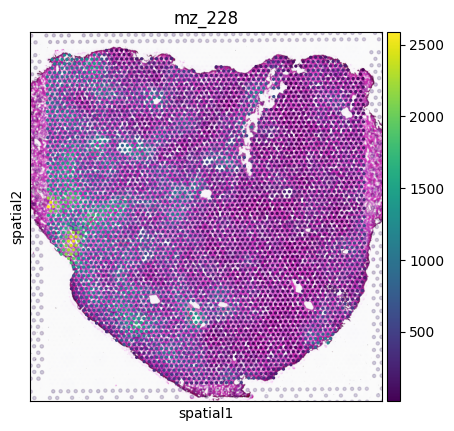

Z43_T


... storing 'sample' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical


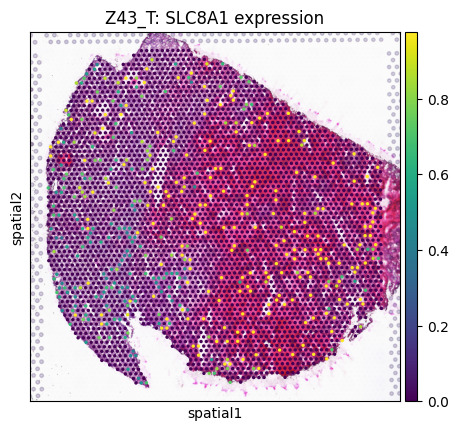

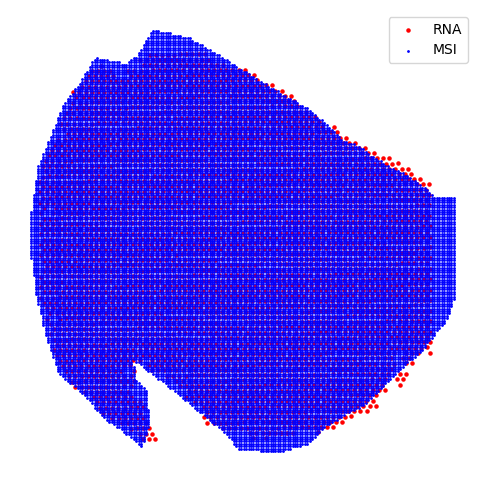

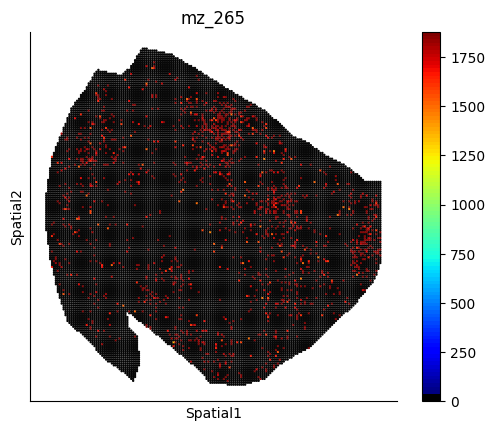

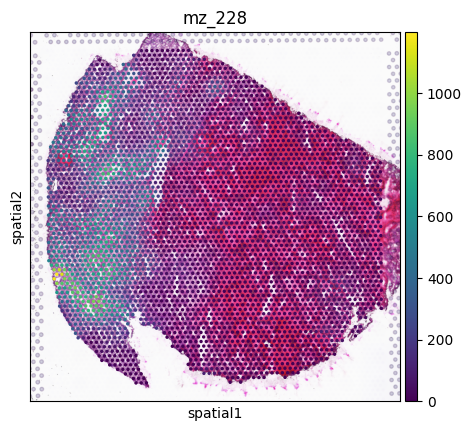

Y7_T


... storing 'sample' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical


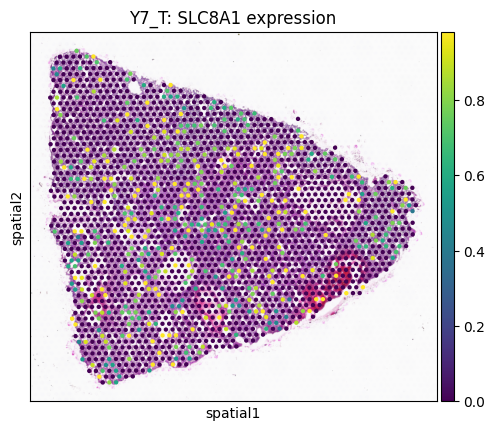

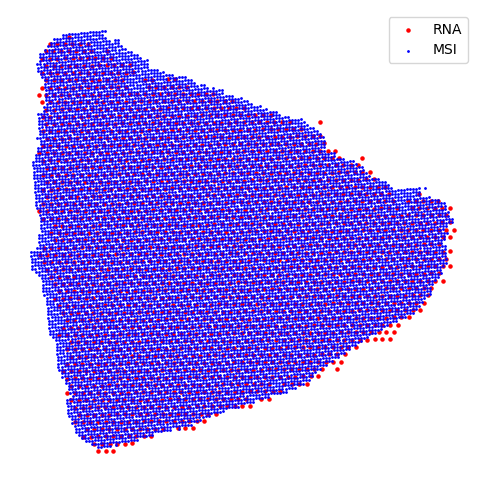

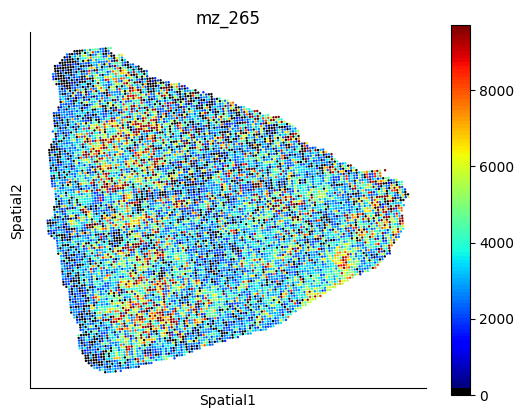

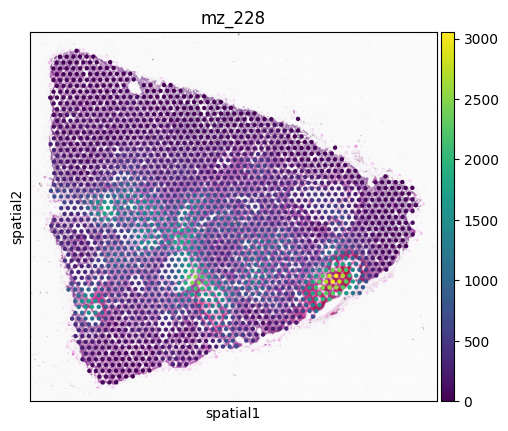

R114_T


... storing 'sample' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical


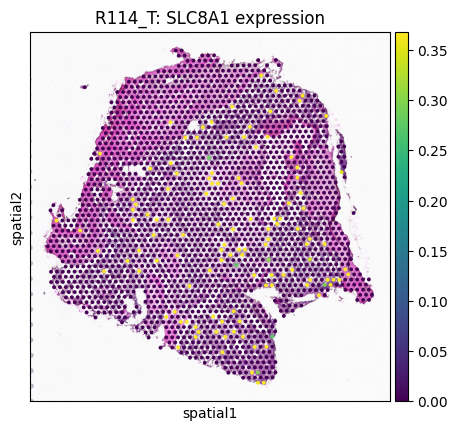

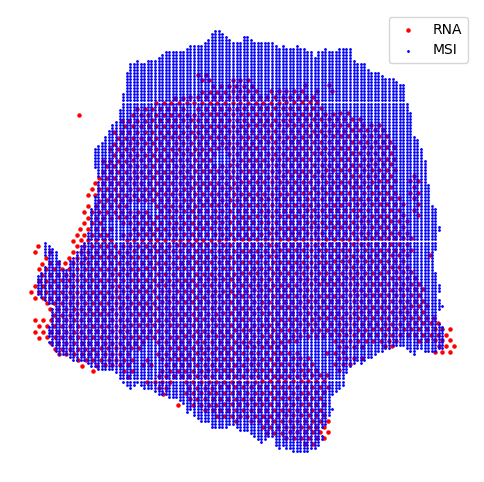

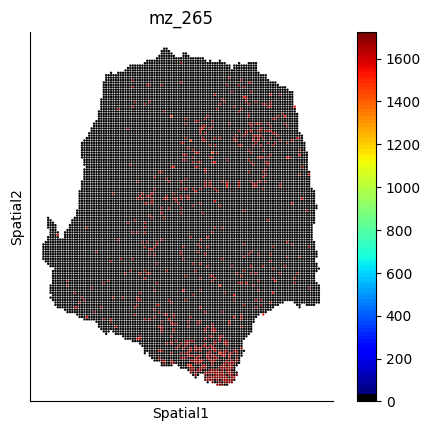

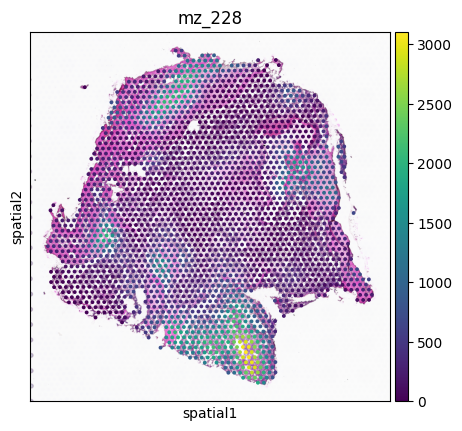

R51_T


... storing 'sample' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical


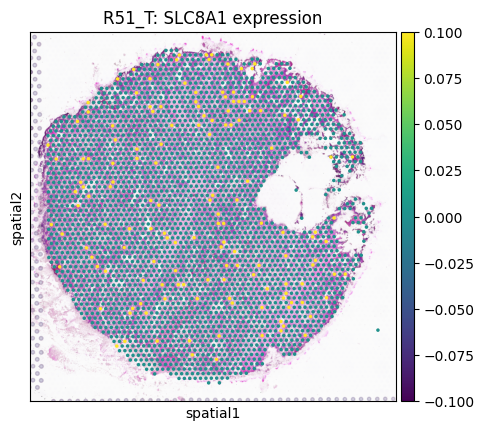

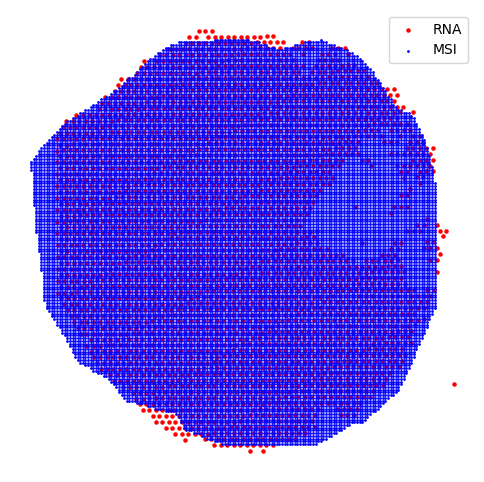

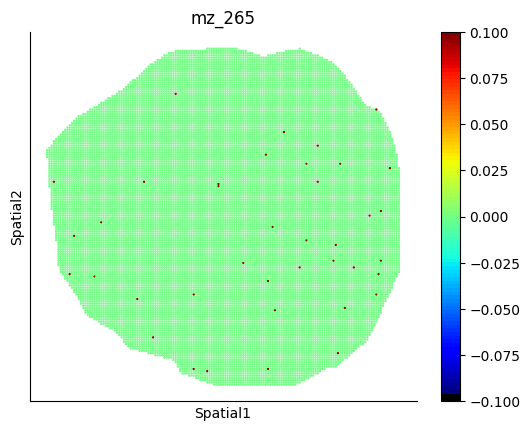

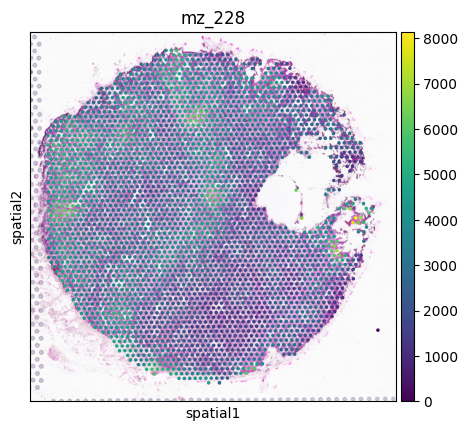

R29_T


... storing 'sample' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical


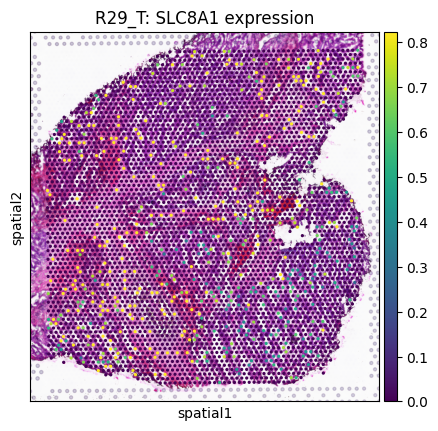

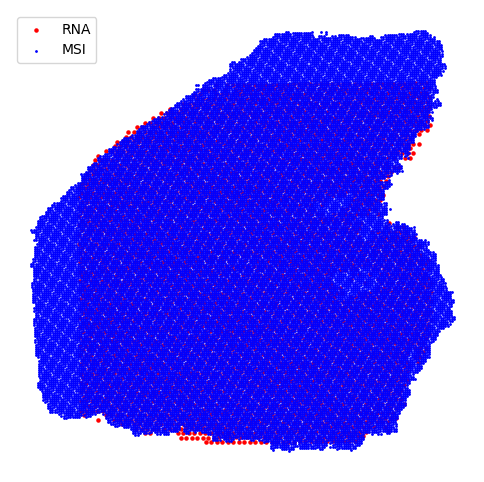

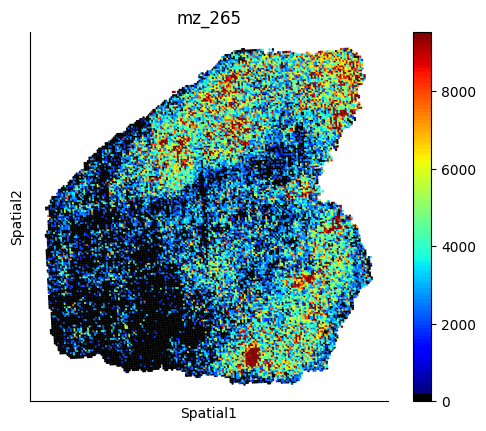

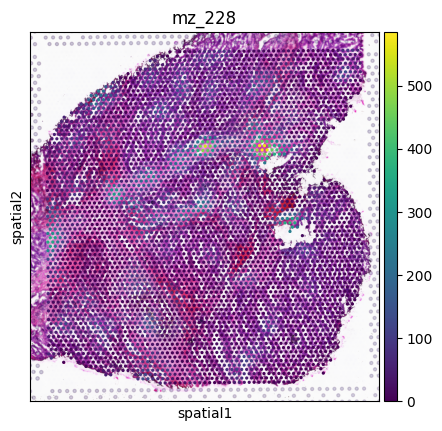

In [13]:
rna_datas = {}
msi_datas = {}
for sample in samples_of_interest:
    print(sample)
    
    rna_path = f'{ST_RAW_DATA_PATH}/{sample}/outs' if 'outs' in os.listdir(f'{ST_RAW_DATA_PATH}/{sample}') else f'{ST_RAW_DATA_PATH}/{sample}'
    rna = sc.read_visium(rna_path)
    rna.obs[['x', 'y']] = rna.obsm['spatial']

    # estimate scaling factor
    sfactor = rna.uns['spatial'][sample]['scalefactors']['fiducial_diameter_fullres']
    
    img_he = rna.uns["spatial"][sample]["images"]["hires"]
    img_he_gray = img_he.mean(axis=2)
    img_he_gray = normalize(img_he_gray)
    
    ### Process RNA
    rna.var_names_make_unique()
    
    # Normalize 
    rna.layers['counts'] = rna.X.copy()
    norm = sc.pp.normalize_total(rna, target_sum=1e4, inplace=False)
    rna.layers["normalized"] = norm["X"]
    rna.layers["log_norm"] = sc.pp.log1p(norm["X"], copy=True)
    
    rna.obs['sample'] = sample
    rna.obs_names = [f'{barcode}_{sample}' for barcode in rna.obs_names]
    
    # gene = 'SLC8A1'
    # sc.pl.spatial(rna, color=[gene], layer='log_norm', vmin='p5', vmax='p95', title=f"{sample}: {gene} expression")
    
    # for mode in ['pos', 'neg']:
    for mode in ['neg']:
        imzml_file = f"{SM_RAW_DATA_PATH}/{sample.replace('_', '-')}-{mode}.imzML"
        parser = ImzMLParser(imzml_file)
        coords = np.array(parser.coordinates)
        
        xs, ys = coords[:, 0], coords[:, 1]
        
        W = xs.max()
        H = ys.max()
        
        x_new = ys
        y_new = W - xs + 1
        
        positions = np.vstack([x_new, y_new]).T
        
        mz_ref = build_reference_mz(parser)

        # X = extract_all_mz(parser, mz_ref)
        
        tol = 0.001

        X = np.zeros((len(parser.coordinates), len(mz_ref)), dtype=np.float32)

        for i in range(len(parser.coordinates)):
            mzs, intensities = parser.getspectrum(i)

            diff = np.abs(mzs[:, None] - mz_ref[None, :]) < tol
            X[i] = (diff * intensities[:, None]).sum(axis=0)
        

        array_row, array_col = positions[:,0], positions[:, 1]

        extra_factor = 0.44 if sample == 'R114_T' else 0.38
        positions = np.round(positions * sfactor * extra_factor).astype(int)

        msi_mode = ad.AnnData(
            X=X,
            obs=pd.DataFrame({"x": coords[:, 0], "y": coords[:, 1], "sample": sample, "mode": mode}),
            var=pd.DataFrame({"mz": mz_ref}, index=[f"mz_{i}" for i in range(len(mz_ref))])
        )
        
        msi_mode.obs.index = msi_mode.obs[['x', 'y']].astype(str).agg('_'.join, axis=1)
        
        msi_mode.obsm['spatial'] = positions
        msi_mode.obs[['x', 'y']] = positions
        msi_mode.obs['array_row'] = array_row
        msi_mode.obs['array_col'] = array_col

        # copy raw intensities
        msi_mode.layers['raw'] = msi_mode.X.copy()
        msi_mode.uns = rna.uns.copy()
        
        msi_mode.obs["total_intensity"] = np.array(msi_mode.X.sum(axis=1)).flatten()
        msi_mode.obs["n_metabolites"] = np.array((msi_mode.X > 0).sum(axis=1)).flatten()
        
        msi_mode = msi_mode[
            (msi_mode.obs["total_intensity"] > np.percentile(msi_mode.obs["total_intensity"], 10)) &
            (msi_mode.obs["n_metabolites"] > np.percentile(msi_mode.obs["n_metabolites"], 10))
        ].copy()
        
        coords_rna = rna.obsm["spatial"]
        coords_msi = msi_mode.obsm["spatial"]
        center_rna = coords_rna.mean(axis=0)
        center_msi = coords_msi.mean(axis=0)
        
        center_rna = coords_rna.mean(axis=0)
        center_msi = coords_msi.mean(axis=0)
        
        shift = center_rna - center_msi
        
        coords_msi += np.round(shift).astype(int)
        
        x_offset = offset_dict[sample][mode]['x_offset'] if sample in offset_dict.keys() else 0
        y_offset = offset_dict[sample][mode]['y_offset'] if sample in offset_dict.keys() else 0
        coords_msi[:, 0] = coords_msi[:, 0] + x_offset
        coords_msi[:, 1] = coords_msi[:, 1] + y_offset
        
        if sample == 'R29_T':
            # --- ROTATION STEP ---
            coords = coords_msi.astype(float)

            # 1. define pivot (top-right)
            pivot = np.array([
                coords[:, 0].max(),
                coords[:, 1].min()
            ])

            # 2. rotation angle (tune this!)
            angle_deg = offset_dict[sample][mode]['degree']
            theta = -np.deg2rad(angle_deg)

            # 3. rotation matrix
            R = np.array([
                [np.cos(theta), -np.sin(theta)],
                [np.sin(theta),  np.cos(theta)]
            ])

            # 4. rotate around pivot
            coords = coords - pivot
            coords = coords @ R.T
            coords = coords + pivot

            # 5. (optional) round back to int if needed
            coords_msi = np.round(coords).astype(int)
            
            x_offset = -500 if mode == 'pos' else 0
            y_offset = - 500
            coords_msi[:, 0] = coords_msi[:, 0] + x_offset
            coords_msi[:, 1] = coords_msi[:, 1] + y_offset
        
        if sample == 'Y7_T':
            # --- ROTATION STEP ---
            coords = coords_msi.astype(float)

            # 1. define pivot (bottom-left)
            pivot = np.array([
                coords[:, 0].min(),
                coords[:, 1].max()
            ])

            # 2. rotation angle (tune this!)
            angle_deg = offset_dict[sample][mode]['degree']
            theta = -np.deg2rad(angle_deg)

            # 3. rotation matrix
            R = np.array([
                [np.cos(theta), -np.sin(theta)],
                [np.sin(theta),  np.cos(theta)]
            ])

            # 4. rotate around pivot
            coords = coords - pivot
            coords = coords @ R.T
            coords = coords + pivot

            # 5. (optional) round back to int if needed
            coords_msi = np.round(coords).astype(int)

        msi_mode.obsm["spatial"] = coords_msi
        msi_mode.obs[["x", "y"]] = coords_msi
        
        plt.figure(figsize=(6,6))
        plt.scatter(coords_rna[:,0], coords_rna[:,1], s=5, c="red", label="RNA")
        plt.scatter(coords_msi[:,0], coords_msi[:,1], s=1, c="blue", label="MSI")
        plt.legend()
        plt.gca().invert_yaxis()
        plt.axis("off")
        plt.show()
        
        metabolite_names = msi_mode.var_names.tolist()
        msi_scores = pd.DataFrame(msi_mode.X,
                                    index=msi_mode.obs_names,
                                    columns=metabolite_names)
        
        coords_obsm_key = 'spatial'
        s = 0.5
        vmin = 'p5'
        vmax = 'p95'
        figsize = (10,10)
        jet = plt.cm.get_cmap("jet", 99)
        colors = np.vstack([[0,0,0,1],[0,0,0,1], jet(np.linspace(0,1,99))])
        cmap = ListedColormap(colors)
        colorbar = True
        swap_y_axis = True
        mz = 300.049
        metab = msi_mode.var[msi_mode.var['mz'] == mz].index[0]

        if isinstance(vmin, str):
            vmin_new = int(vmin.split('p')[1])
            vmin_new = np.percentile(msi_scores[metab], vmin_new)
        else:
            vmin_new = vmin
        if isinstance(vmax, str):
            vmax_new = int(vmax.split('p')[1])
            vmax_new = np.percentile(msi_scores[metab], vmax_new)
        else:
            vmax_new = vmax
        plot_interaction(msi_mode, msi_scores, metab, coords_obsm_key, s, vmin_new, vmax_new, figsize, cmap, colorbar, swap_y_axis, metab)
        plt.show()
        plt.close()
        
        ### Process metabolites
        msi_mode.X = msi_mode.layers['raw'].copy()
        msi_mode.var['max_intensity'] = msi_mode.X.sum(axis=0)

        # drop duplicates
        msi_mode = msi_mode[:, ~msi_mode.var.index.duplicated()]
        sc.pp.filter_cells(msi_mode, min_counts=200)
        
        msi_mode.obs_names = [f'{barcode}_{sample}_{mode}' for barcode in msi_mode.obs_names]
        
        # Compute distances for each extra modality
        bandwidth = 500
        cutoff = 0.1
        # distances of metabolties to RNA
        reference = msi_mode.obsm["spatial"]
        
        li.utils.spatial_neighbors(rna, bandwidth=bandwidth, cutoff=cutoff, spatial_key="spatial", reference=reference, set_diag=False, standardize=False)
        
        W = rna.obsm['spatial_connectivities']
        row_sums = np.array(W.sum(axis=1)).flatten()
        row_sums[row_sums == 0] = 1  # avoid division by zero
        W_norm = W.multiply(1 / row_sums[:, None])
        
        msi_data = msi_mode.X
        msi_on_rna = W_norm @ msi_data
        rna.obsm[f'msi_{mode}'] = msi_on_rna
        
        metabolite_names = msi_mode.var_names.tolist()
        if mode == 'neg':
            metab = msi_mode.var[msi_mode.var['mz'] == 271.103].index[0]
            idx = metabolite_names.index(metab)
            
            rna.obs[metab] = rna.obsm[f'msi_{mode}'][:, idx]
            
            sc.pl.spatial(rna, color=[metab]) # plot dopamine
        
        msi_datas[f"{sample}_{mode}"] = msi_mode

    rna_datas[f"{sample}"] = rna

    # # Write
    # mdata = mu.MuData({'rna':rna, 'msi':msi})
    # mdata = mu.MuData(mdata.mod)
    # mdata.write_h5mu(os.path.join(slide_path, "sma.h5mu"))

In [44]:
msi_pos_datas = {}
msi_neg_datas = {}
for sample, msi_ in msi_datas.items():
    if "pos" in sample:
        msi_pos_datas[sample] = msi_
    else:
        msi_neg_datas[sample] = msi_

In [45]:
for sample, msi_ in msi_datas.items():
    # msi_.write(os.path.join(f"{ADATA_PATH}/{sample}_msi.h5ad"))
    msi_.write(os.path.join(f"{ADATA_PATH}/{sample}_neg_msi.h5ad"))

... storing 'sample' as categorical
... storing 'mode' as categorical
... storing 'sample' as categorical
... storing 'mode' as categorical
... storing 'sample' as categorical
... storing 'mode' as categorical


... storing 'sample' as categorical
... storing 'mode' as categorical
... storing 'sample' as categorical
... storing 'mode' as categorical
... storing 'sample' as categorical
... storing 'mode' as categorical


In [46]:
rna = ad.concat(rna_datas.values(), join="outer")
# msi_pos = ad.concat(msi_pos_datas.values(), join="outer")
msi_neg = ad.concat(msi_neg_datas.values(), join="outer")

In [47]:
# msi_pos.var['mz'] = msi_pos_datas['R29_T_pos'].var['mz']
msi_neg.var['mz'] = msi_neg_datas['R29_T_neg'].var['mz']

In [48]:
# rna.write(os.path.join(f"{ADATA_PATH}/rna.h5ad"))
rna.write(os.path.join(f"{ADATA_PATH}/neg_rna.h5ad"))
# msi_pos.write(os.path.join(f"{ADATA_PATH}/pos_msi.h5ad"))
msi_neg.write(os.path.join(f"{ADATA_PATH}/neg_msi.h5ad"))